In [5]:
import os
print(os.getcwd())

C:\Users\CH V S PARDHU\bluestock_mf_capstone


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

In [6]:
fund_master = pd.read_csv("data/raw/01_fund_master.csv")

nav = pd.read_csv("data/processed/clean_nav_history.csv")

aum = pd.read_csv("data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("data/processed/05_category_inflows_clean.csv")

folio = pd.read_csv("data/processed/06_industry_folio_count_clean.csv")

transactions = pd.read_csv("data/processed/clean_investor_transactions.csv")

holdings = pd.read_csv("data/processed/09_portfolio_holdings_clean.csv")

In [7]:
print(fund_master.shape)
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(category.shape)
print(folio.shape)
print(transactions.shape)
print(holdings.shape)

(40, 15)
(46000, 3)
(90, 5)
(48, 6)
(144, 3)
(21, 6)
(32778, 13)
(322, 8)


In [8]:
print(nav.columns.tolist())
print(aum.columns.tolist())
print(sip.columns.tolist())
print(category.columns.tolist())
print(folio.columns.tolist())
print(transactions.columns.tolist())
print(holdings.columns.tolist())

['amfi_code', 'date', 'nav']
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
['month', 'category', 'net_inflow_crore']
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


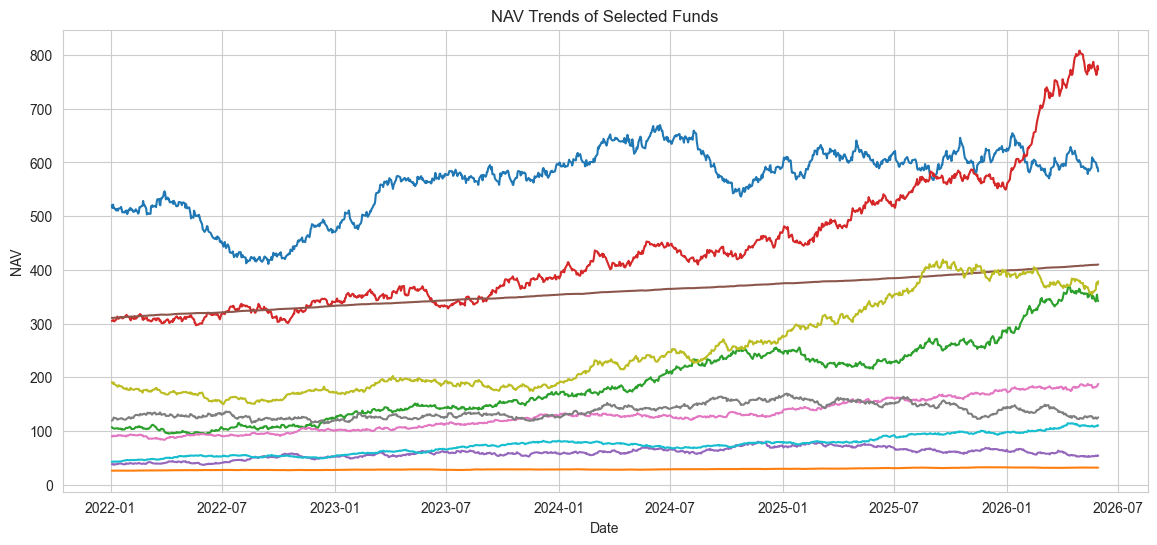

In [57]:
plt.figure(figsize=(14,6))

for code in nav["amfi_code"].unique()[:10]:
    fund_data = nav[nav["amfi_code"] == code]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(code)
    )

plt.title("NAV Trends of Selected Funds")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.savefig(
    "reports/nav_trend_analysis.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

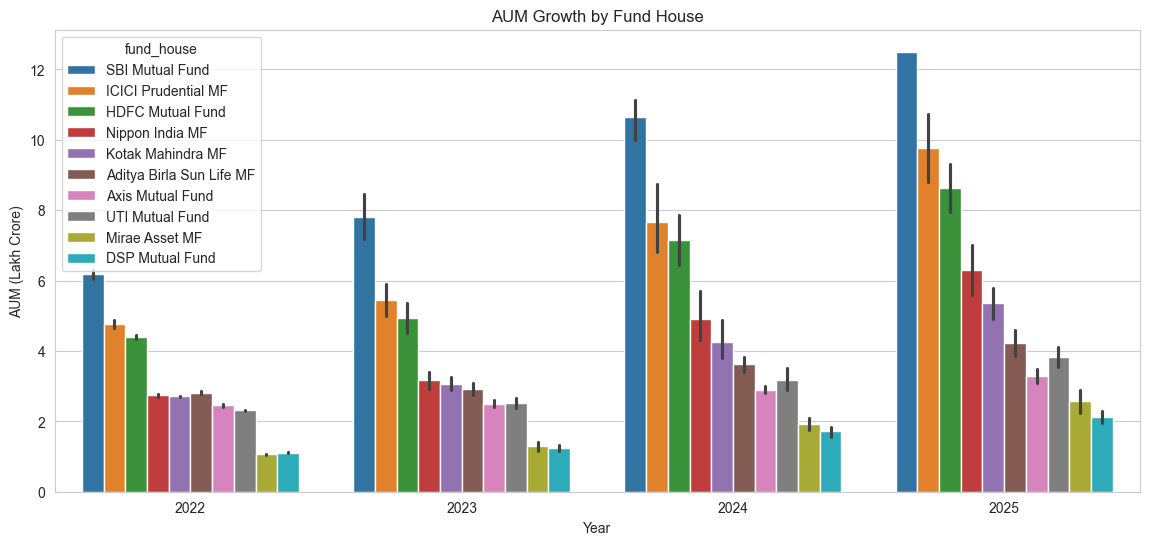

In [58]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.savefig(
    "reports/aum_growth_by_fund_house.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

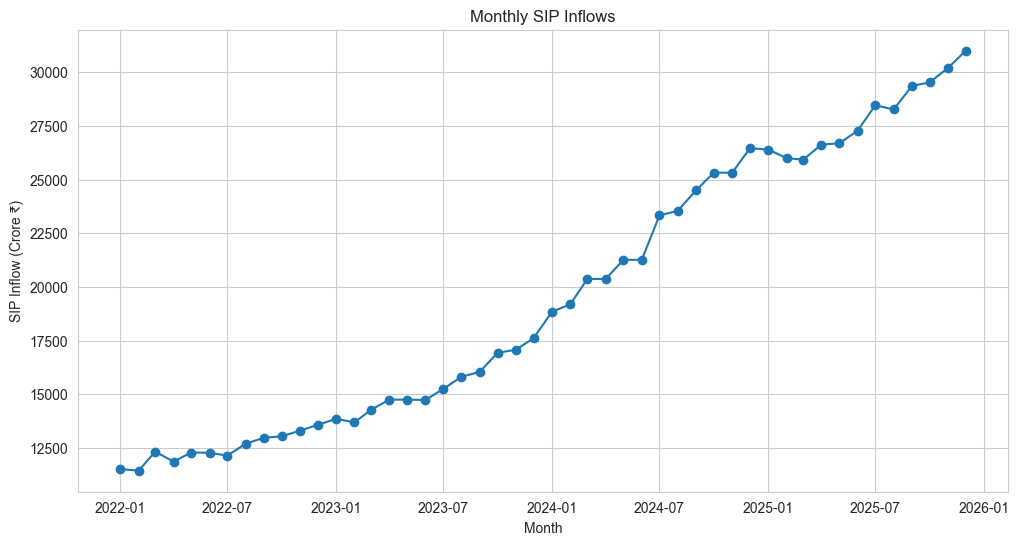

In [61]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")

plt.savefig(
    "reports/monthly_sip_inflows.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

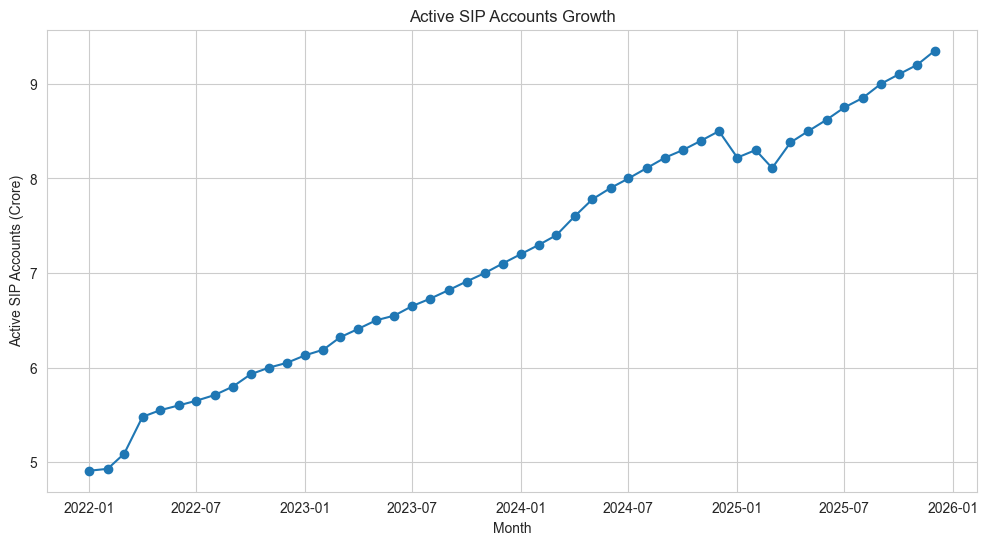

In [62]:
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["active_sip_accounts_crore"],
    marker="o"
)

plt.title("Active SIP Accounts Growth")
plt.xlabel("Month")
plt.ylabel("Active SIP Accounts (Crore)")

plt.savefig(
    "reports/active_sip_accounts_growth.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

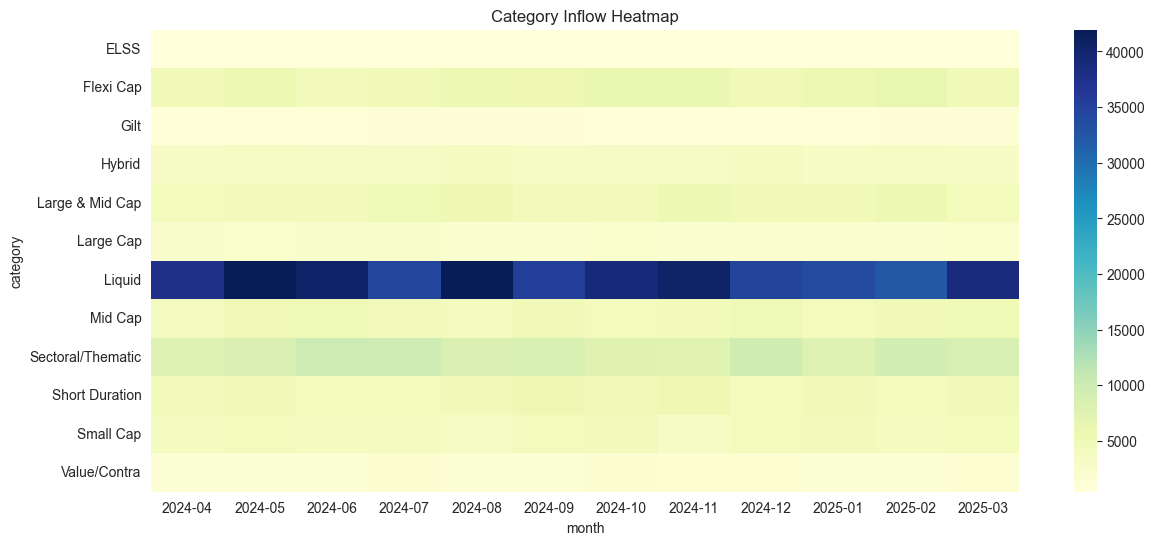

In [63]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    "reports/category_inflow_heatmap.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

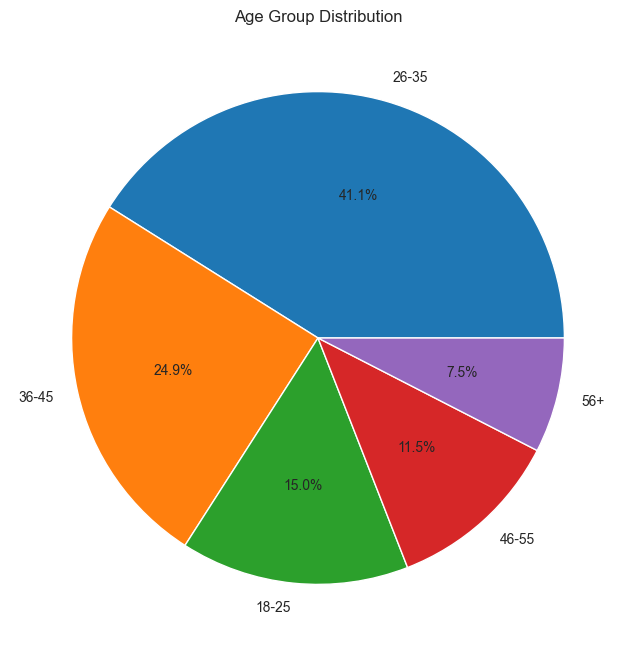

In [64]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")

plt.savefig(
    "reports/age_group_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

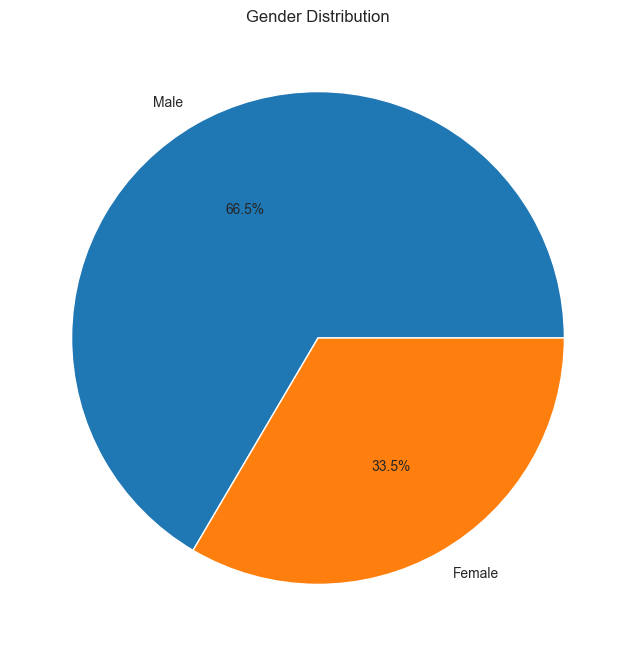

In [65]:
plt.figure(figsize=(8,8))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.savefig(
    "reports/gender_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [42]:
plt.savefig("reports/chart_name.png")

<Figure size 640x480 with 0 Axes>

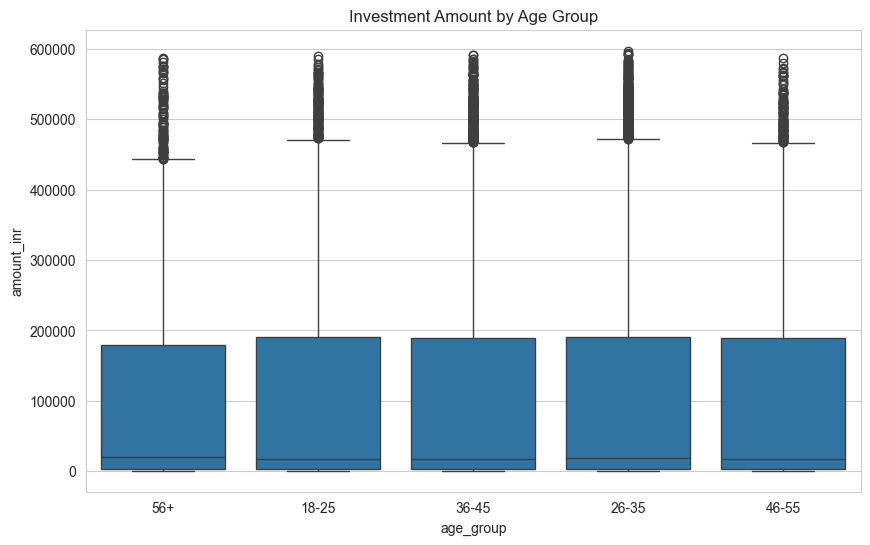

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.show()

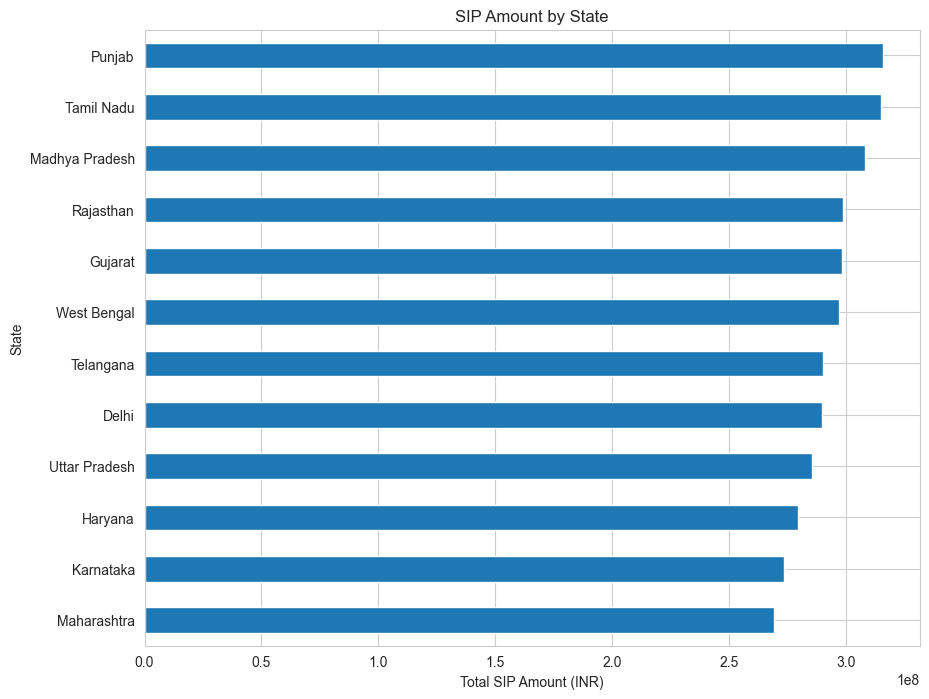

In [66]:
state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

state_amount.plot(kind="barh")

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.savefig(
    "reports/state_wise_sip_amount.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

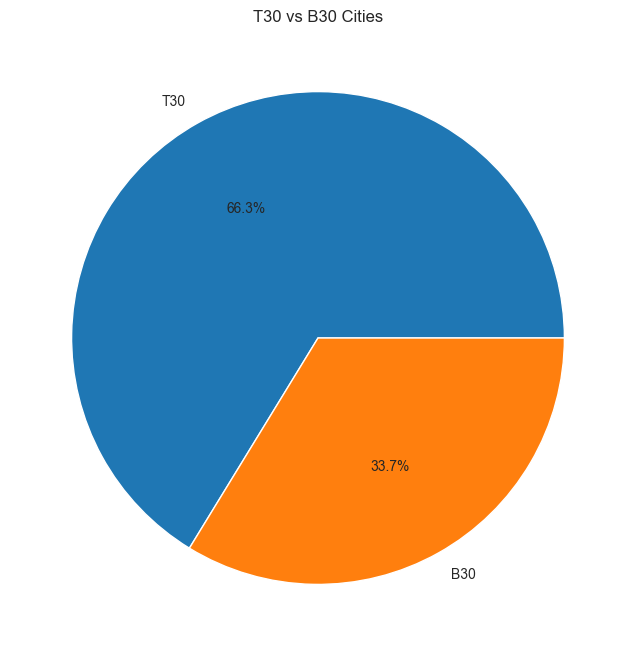

In [67]:
plt.figure(figsize=(8,8))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Cities")

plt.savefig(
    "reports/t30_vs_b30_cities.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

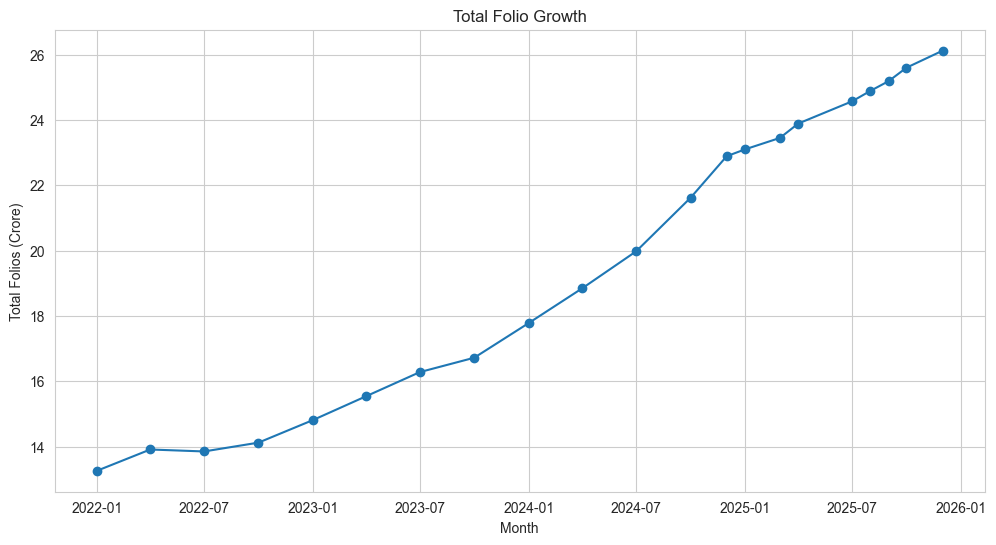

In [68]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Total Folio Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.savefig(
    "reports/total_folio_growth.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

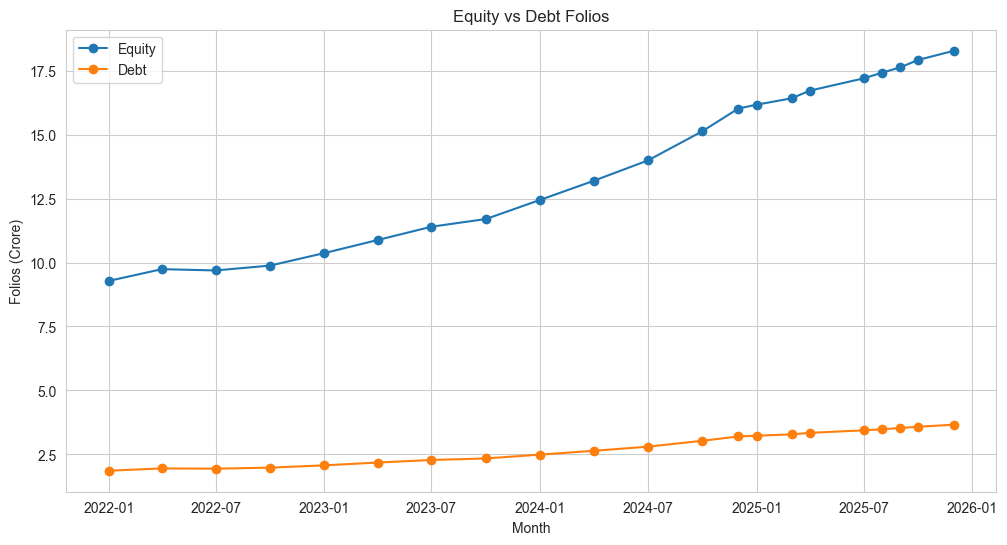

In [70]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["equity_folios_crore"],
    label="Equity",
    marker="o"
)

plt.plot(
    folio["month"],
    folio["debt_folios_crore"],
    label="Debt",
    marker="o"
)

plt.legend()

plt.title("Equity vs Debt Folios")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.savefig(
    "reports/equity_vs_debt_folios.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

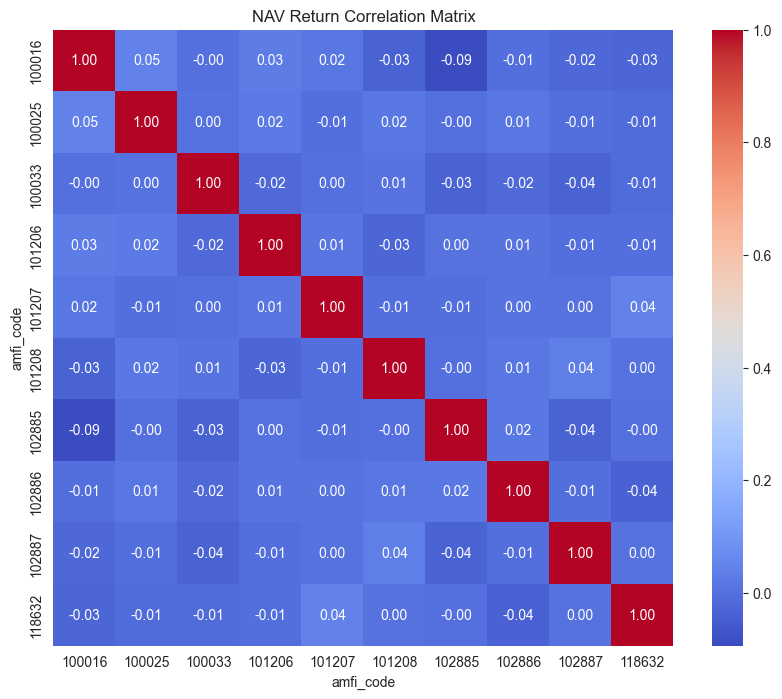

In [71]:
top10 = nav["amfi_code"].unique()[:10]

corr_df = nav[
    nav["amfi_code"].isin(top10)
]

pivot = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")

plt.savefig(
    "reports/nav_return_correlation_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

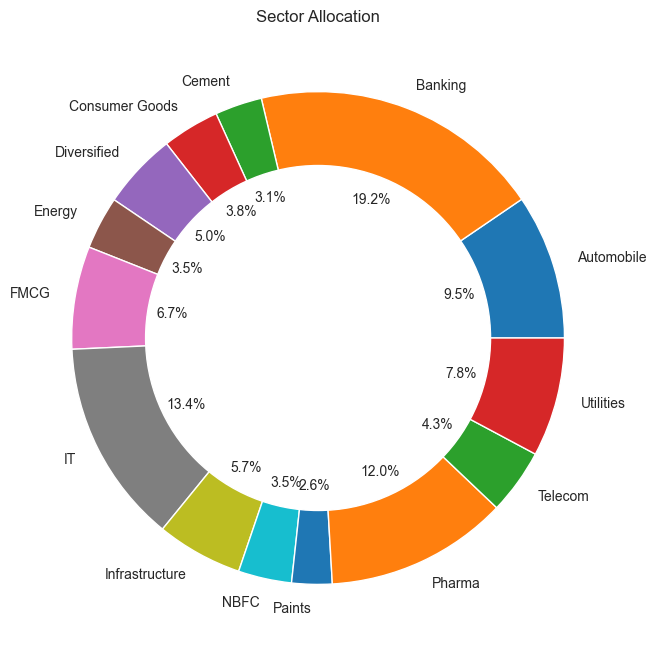

In [72]:
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

centre = plt.Circle((0,0), 0.70, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre)

plt.title("Sector Allocation")

plt.savefig(
    "reports/sector_allocation_donut.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

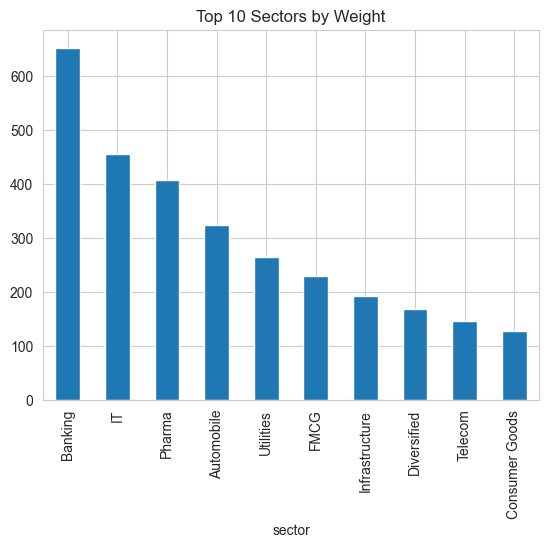

In [73]:
top_sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sector.plot(
    kind="bar"
)

plt.title("Top 10 Sectors by Weight")
plt.show()

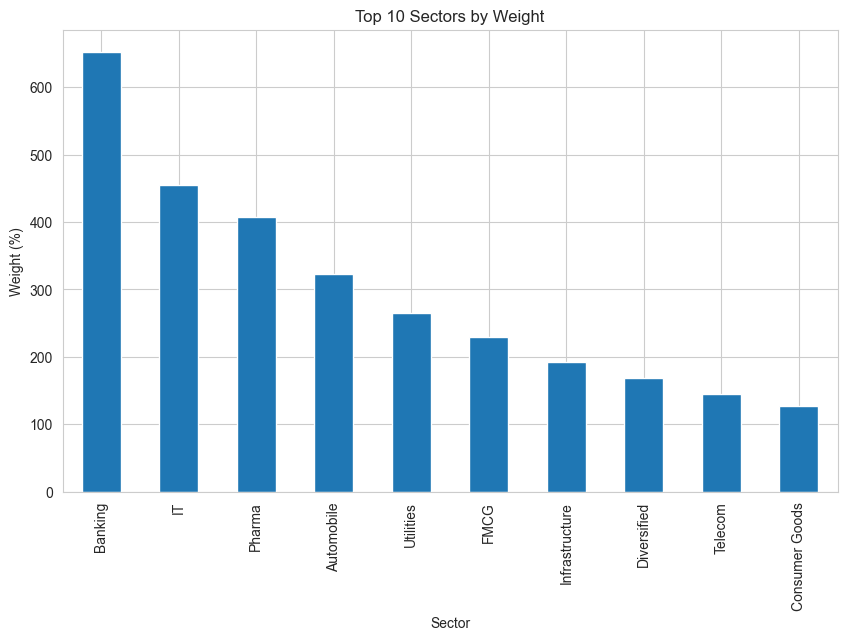

In [75]:
plt.figure(figsize=(10,6))

top_sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sector.plot(kind="bar")

plt.title("Top 10 Sectors by Weight")
plt.xlabel("Sector")
plt.ylabel("Weight (%)")

plt.savefig(
    "reports/top_10_sectors_by_weight.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

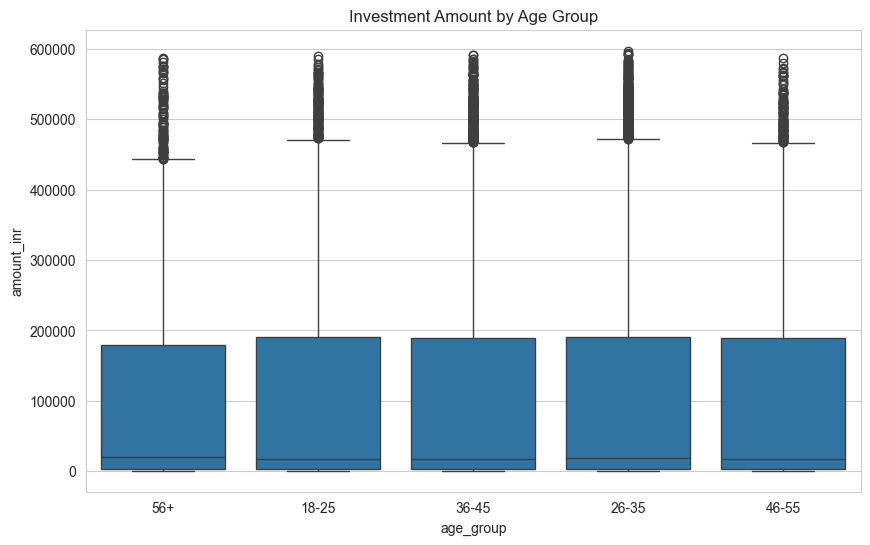

In [77]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.savefig(
    "reports/investment_amount_by_age_group.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

1. SIP inflows show a strong upward trend from 2022 to 2025.
2. Active SIP accounts increased steadily over the study period.
3. SBI Mutual Fund maintains one of the highest AUM levels.
4. Equity folios dominate investor participation.
5. Age group 26–35 contributes the largest share of investments.
6. T30 cities contribute a larger proportion of transactions.
7. Financial and Technology sectors hold significant portfolio weight.
8. NAV correlations are high among diversified equity funds.
9. Category inflows vary significantly across months.
10. Folio counts nearly doubled between 2022 and 2025.

In [78]:
import os
print(os.listdir("reports"))

['active_sip_accounts_growth.png', 'age_group_distribution.png', 'aum_growth_by_fund_house.png', 'category_inflow_heatmap.png', 'day1_data_quality_summary.txt', 'equity_vs_debt_folios.png', 'gender_distribution.png', 'investment_amount_by_age_group.png', 'monthly_sip_inflows.png', 'nav_return_correlation_matrix.png', 'nav_trend_analysis.png', 'sector_allocation_donut.png', 'state_wise_sip_amount.png', 't30_vs_b30_cities.png', 'top_10_sectors_by_weight.png', 'total_folio_growth.png']
